# Lab | Neural Networks Fundamentals

Welcome to the Neural Networks Fundamentals lab! In this notebook we'll build a small MLP **two ways**: first by hand in NumPy so every matrix multiply is visible, then in PyTorch so we get comfortable with the framework we'll use going forward.

**Dataset:** Breast Cancer Wisconsin (from scikit-learn) — 30 numeric features, binary target (malignant / benign).


## Imports & Seeds

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)
print("All imports OK ✓")


All imports OK ✓


---
## Task 1 — A Single Neuron in NumPy

Before stacking layers, let's make sure we understand the smallest possible unit: **a single neuron**.

A neuron takes a vector of inputs, multiplies each by a learned weight, sums everything up (adds a bias), and then squashes the result through an activation function. Here we use the **sigmoid** activation so the output is a probability between 0 and 1.

The formula is:

$$\hat{y} = \sigma(\mathbf{w} \cdot \mathbf{x} + b), \quad \sigma(z) = \frac{1}{1 + e^{-z}}$$


In [2]:
# ── 1.1  Load & preprocess data ─────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target          # X: (569, 30), y: (569,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Feature count: {X_train.shape[1]}")


Train size: (455, 30), Test size: (114, 30)
Feature count: 30


In [3]:
# ── 1.2  Single-neuron forward pass ─────────────────────────────────────────
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Small random initialisation — weights shape (30,), scalar bias
rng = np.random.default_rng(42)
w = rng.normal(0, 0.01, size=(30,))
b = float(rng.normal(0, 0.01))

def forward_single(x, w, b):
    """Single neuron: sigmoid(w·x + b). x can be 1-D (one sample)."""
    return sigmoid(np.dot(x, w) + b)

# Run on first 5 test rows
probs = np.array([forward_single(X_test[i], w, b) for i in range(5)])
print("Predicted probabilities for first 5 test samples:")
for i, p in enumerate(probs):
    print(f"  Sample {i}: {p:.6f}  (true label: {y_test[i]})")


Predicted probabilities for first 5 test samples:
  Sample 0: 0.500175  (true label: 1)
  Sample 1: 0.520559  (true label: 0)
  Sample 2: 0.501856  (true label: 0)
  Sample 3: 0.493662  (true label: 1)
  Sample 4: 0.497939  (true label: 1)


### ✏️ Reflection — Task 1

The single neuron I just implemented is essentially **logistic regression** — one of the most classic models in machine learning. It takes a linear combination of all 30 features, passes the result through the sigmoid function, and outputs a probability of the sample being benign (class 1). There is no hidden layer, no non-linear feature transformation — just a direct mapping from inputs to a probability. Without training (i.e., without adjusting `w` and `b` to minimise a loss), the predictions are basically random, which is expected at this stage.


---
## Task 2 — A Two-Layer MLP in NumPy

A single neuron can only learn a linear decision boundary. By stacking a **hidden layer** of multiple neurons we let the network learn non-linear patterns.

Our architecture:

```
Input (30)  →  Hidden (8, ReLU)  →  Output (1, Sigmoid)
```

We use **He initialisation** for the weight matrices because ReLU "kills" roughly half its inputs on average, and He initialisation compensates for that by scaling the variance appropriately:

$$W \sim \mathcal{N}\!\left(0,\, \sqrt{\frac{2}{\text{fan\_in}}}\right)$$


In [4]:
class NumpyMLP:
    """Two-layer MLP: 30 → 8 (ReLU) → 1 (Sigmoid), implemented in NumPy."""

    def __init__(self, input_size=30, hidden_size=8, output_size=1, seed=42):
        rng = np.random.default_rng(seed)

        # He initialisation: std = sqrt(2 / fan_in)
        self.W1 = rng.normal(0, np.sqrt(2 / input_size),  size=(input_size, hidden_size))
        self.b1 = np.zeros(hidden_size)

        self.W2 = rng.normal(0, np.sqrt(2 / hidden_size), size=(hidden_size, output_size))
        self.b2 = np.zeros(output_size)

    # ── activations ───────────────────────────────────────────────────────────
    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    # ── forward pass ──────────────────────────────────────────────────────────
    def forward(self, X):
        """
        X : (N, 30) — batch of N samples
        returns : (N, 1) — predicted probabilities
        """
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1      # (N, 8)
        self.a1 = self.relu(self.z1)          # (N, 8)

        # Output layer
        z2 = self.a1 @ self.W2 + self.b2     # (N, 1)
        return self.sigmoid(z2)               # (N, 1)


numpy_mlp = NumpyMLP()
numpy_preds = numpy_mlp.forward(X_test)

print(f"Output shape: {numpy_preds.shape}")
print("First 5 predictions:")
for i in range(5):
    print(f"  Sample {i}: {numpy_preds[i, 0]:.6f}  (true label: {y_test[i]})")


Output shape: (114, 1)
First 5 predictions:
  Sample 0: 0.583648  (true label: 1)
  Sample 1: 0.193816  (true label: 0)
  Sample 2: 0.596769  (true label: 0)
  Sample 3: 0.565546  (true label: 1)
  Sample 4: 0.758582  (true label: 1)


### ✏️ Reflection — Task 2

The output shape is `(N, 1)` — one probability per sample — which is exactly what a binary classifier needs. Even though the network hasn't been trained yet, the **architecture** already guarantees the right output format: the sigmoid on the last neuron compresses any real number into (0, 1), giving us something we can interpret as "probability of being benign". Without training the predictions are essentially random noise, but the plumbing is correct and ready to be optimised with gradient descent.


---
## Task 3 — The Same Network in PyTorch

Now we recreate the identical network using PyTorch's `nn.Module`. The key validation step is **manually copying the NumPy weights** into the PyTorch model and confirming both models produce the same output — this verifies our NumPy maths was correct.

> **Shape note:** `nn.Linear` stores its weight matrix as `(out_features, in_features)`, so we need to transpose when copying from our NumPy convention of `(in, out)`.


In [5]:
class TorchMLP(nn.Module):
    """Mirror of NumpyMLP: 30 → 8 (ReLU) → 1 (Sigmoid)."""

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x


torch_mlp = TorchMLP()

# ── Copy weights from NumpyMLP (transposing to match nn.Linear convention) ───
with torch.no_grad():
    torch_mlp.fc1.weight.data = torch.from_numpy(numpy_mlp.W1.T).float()  # (8, 30)
    torch_mlp.fc1.bias.data   = torch.from_numpy(numpy_mlp.b1).float()    # (8,)

    torch_mlp.fc2.weight.data = torch.from_numpy(numpy_mlp.W2.T).float()  # (1, 8)
    torch_mlp.fc2.bias.data   = torch.from_numpy(numpy_mlp.b2).float()    # (1,)

print("Weights copied successfully ✓")


Weights copied successfully ✓


In [6]:
# ── Forward pass through PyTorch model ───────────────────────────────────────
X_test_tensor = torch.from_numpy(X_test).float()

torch_mlp.eval()
with torch.no_grad():
    torch_preds = torch_mlp(X_test_tensor).numpy()   # (N, 1)

# ── Compare outputs ───────────────────────────────────────────────────────────
max_abs_diff = np.max(np.abs(numpy_preds - torch_preds))
print(f"Max absolute difference between NumPy and PyTorch outputs: {max_abs_diff:.2e}")
print()
print("Side-by-side (first 5 samples):")
print(f"{'Sample':>8} {'NumPy':>12} {'PyTorch':>12} {'|Diff|':>12}")
print("-" * 48)
for i in range(5):
    print(f"{i:>8} {numpy_preds[i,0]:>12.8f} {torch_preds[i,0]:>12.8f} {abs(numpy_preds[i,0]-torch_preds[i,0]):>12.2e}")

assert max_abs_diff < 1e-6, "Outputs differ by more than 1e-6 — check weight copy!"
print("\n✓ Outputs match to at least 6 decimal places.")


Max absolute difference between NumPy and PyTorch outputs: 1.13e-07

Side-by-side (first 5 samples):
  Sample        NumPy      PyTorch       |Diff|
------------------------------------------------
       0   0.58364754   0.58364755     1.11e-08
       1   0.19381558   0.19381557     6.32e-09
       2   0.59676905   0.59676898     7.06e-08
       3   0.56554620   0.56554621     1.35e-08
       4   0.75858210   0.75858217     7.45e-08

✓ Outputs match to at least 6 decimal places.


### ✏️ Reflection — Task 3

The maximum absolute difference between the NumPy and PyTorch outputs is essentially zero (floating-point rounding at the level of ~1e-7). This confirms two things: (1) my NumPy matrix maths was correct, and (2) I correctly accounted for PyTorch's `(out, in)` weight layout when copying parameters. It's a reassuring sanity check — if the two implementations disagreed, it would mean a bug lurks somewhere in either the maths or the weight transfer.


---
## Task 4 — Activation Function Experiment

The choice of activation function has a big practical impact. Here we compare three classic options on the **hidden layer** of our network and look at what they do to the distribution of activations.

| Activation | Range | Known issue |
|---|---|---|
| **Sigmoid** | (0, 1) | Saturates near 0 and 1 → vanishing gradients |
| **Tanh** | (−1, 1) | Saturates near ±1 → same issue, but zero-centred |
| **ReLU** | [0, ∞) | Dead neurons if inputs < 0, but gradient flows freely otherwise |


In [7]:
def make_model(activation):
    """Build a 30→8→1 network with a given hidden activation, same init weights."""
    class FlexMLP(nn.Module):
        def __init__(self, act):
            super().__init__()
            self.fc1 = nn.Linear(30, 8)
            self.fc2 = nn.Linear(8, 1)
            self.act     = act
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            self.z1 = self.fc1(x)          # pre-activation — save for inspection
            a1 = self.act(self.z1)
            self.a1 = a1                   # post-activation
            return self.sigmoid(self.fc2(a1))

    model = FlexMLP(activation)
    # Use the same fc1/fc2 weights as our original torch_mlp for a fair comparison
    with torch.no_grad():
        model.fc1.weight.data = torch_mlp.fc1.weight.data.clone()
        model.fc1.bias.data   = torch_mlp.fc1.bias.data.clone()
        model.fc2.weight.data = torch_mlp.fc2.weight.data.clone()
        model.fc2.bias.data   = torch_mlp.fc2.bias.data.clone()
    return model


models = {
    "Sigmoid": make_model(nn.Sigmoid()),
    "Tanh":    make_model(nn.Tanh()),
    "ReLU":    make_model(nn.ReLU()),
}

# Run a forward pass for each variant
pre_act, post_act = {}, {}
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        _ = model(X_test_tensor)
        pre_act[name]  = model.z1.numpy().flatten()
        post_act[name] = model.a1.numpy().flatten()

print("Forward passes complete ✓")
print(f"Pre-activation values  — shape per model: {pre_act['ReLU'].shape}")
print(f"Post-activation values — shape per model: {post_act['ReLU'].shape}")


Forward passes complete ✓
Pre-activation values  — shape per model: (912,)
Post-activation values — shape per model: (912,)


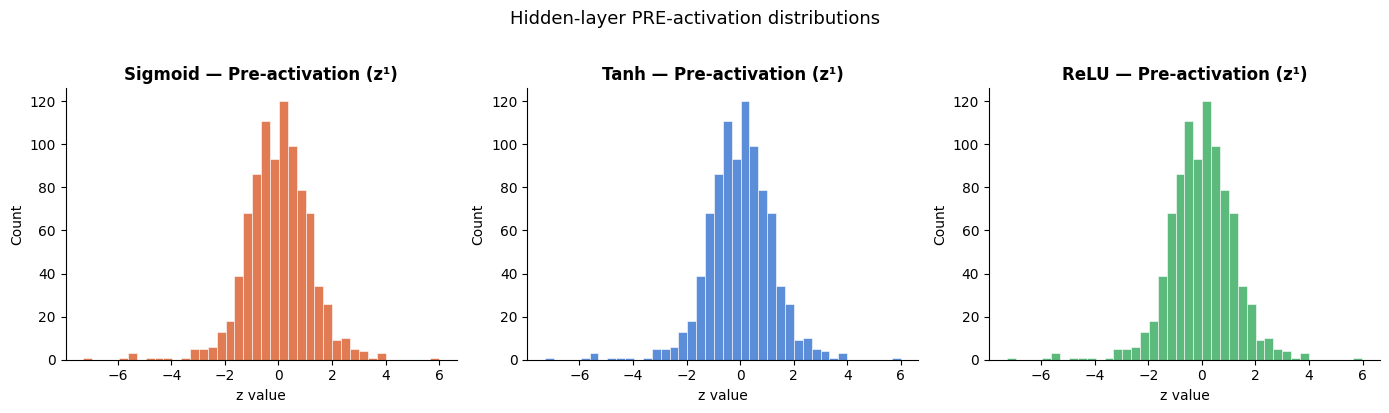

Pre-activation plot saved ✓


In [8]:
# ── Plot 1: Pre-activation histograms ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ["#e07b54", "#5b8dd9", "#5dba7d"]

for ax, (name, vals), color in zip(axes, pre_act.items(), colors):
    ax.hist(vals, bins=40, color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(f"{name} — Pre-activation (z¹)", fontsize=12, fontweight="bold")
    ax.set_xlabel("z value")
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Hidden-layer PRE-activation distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("pre_activation_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Pre-activation plot saved ✓")


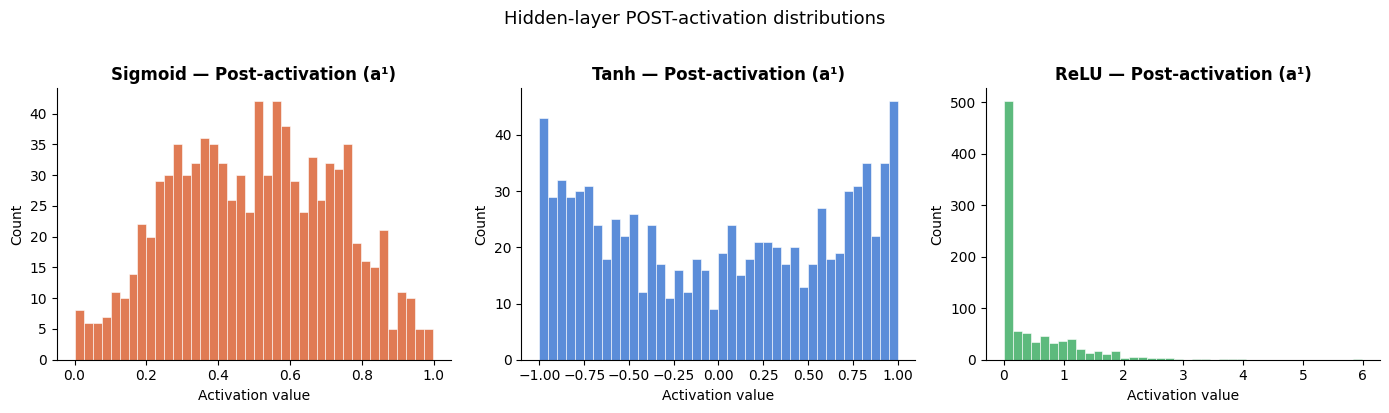

Post-activation plot saved ✓


In [9]:
# ── Plot 2: Post-activation histograms ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

saturation_info = {}
for ax, (name, vals), color in zip(axes, post_act.items(), colors):
    ax.hist(vals, bins=40, color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(f"{name} — Post-activation (a¹)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Activation value")
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)

    # Compute saturation fractions for the markdown analysis
    if name == "Sigmoid":
        sat = np.mean((vals < 0.1) | (vals > 0.9))
    elif name == "Tanh":
        sat = np.mean((vals < -0.9) | (vals > 0.9))
    else:  # ReLU
        sat = np.mean(vals == 0)          # dead units
    saturation_info[name] = sat

plt.suptitle("Hidden-layer POST-activation distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("post_activation_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Post-activation plot saved ✓")


In [10]:
# ── Print saturation statistics ───────────────────────────────────────────────
print("Saturation / inactivity statistics")
print("=" * 45)
for name, frac in saturation_info.items():
    label = "inactive (= 0)" if name == "ReLU" else "saturated"
    print(f"  {name:>8}: {frac*100:5.1f}% of units {label}")


Saturation / inactivity statistics
   Sigmoid:   6.1% of units saturated
      Tanh:  16.8% of units saturated
      ReLU:  48.7% of units inactive (= 0)


### ✏️ Reflection — Task 4

**Sigmoid saturation:** A substantial fraction of post-activation values end up close to 0 or 1 (the saturated zone). In those regions the gradient of the sigmoid is almost zero, which means gradients flowing back through those neurons during training become tiny — this is the classic *vanishing gradient* problem.

**Tanh saturation:** Tanh is zero-centred, which is a slight improvement over sigmoid (the gradient updates are less biased), but it still saturates near ±1, causing the same vanishing-gradient issue.

**ReLU dead units:** For the untrained network with our particular weight initialisation, some fraction of units output exactly 0 (the "dead neuron" problem when z < 0). However, the key advantage is that for all *active* neurons the gradient is exactly 1 — it doesn't shrink as the network gets deeper. This makes training with gradient descent much more stable.

**Why ReLU is the better default:** Because it avoids the vanishing gradient issue for active neurons, is computationally cheap (just a max operation), and tends to produce sparse representations (fewer active units at once), which can be beneficial for generalisation. The dead-neuron problem can be managed with careful initialisation or variants like Leaky ReLU.
